# 1. Bibliotecas

In [85]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ignorar avisos
import warnings
warnings.filterwarnings("ignore")


# 2. Funções

In [2]:
def gerar_dataset_vendas(n_registros=200, seed=42):
    
    """
    Gera um dataset sintético de vendas com dados intencionalmente sujos.
    """
    
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse", "Headset"]
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares",
                  "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos",
                  "Headset": "Periféricos"}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco_base = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
                      "Monitor": 1200, "Teclado": 250, "Mouse": 120, "Headset": 350}[produto]
        preco = round(preco_base * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja)

        dados.append({
            "id_venda": i + 1,
            "data_venda": data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVÁLIDA",
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

In [3]:
# Usado a função display para melhorar a visualização de forma tabular. 
# Tambem adicionada a visualisação do tail do df e resumo das estatistico das variaveis categóricas.
def inspecionar_dados(df):
    
    """
    Exibe informações básicas do DataFrame.
    """
    
    print(f"{30*'='}\n INSPEÇÃO INICIAL DO DATASET \n{30*'='}\n")
    print("- ESTRUTURA:")
    print(f"   Quantidade de linhas: {df.shape[0]}")
    print(f"   Quantidade de colunas: {df.shape[1]}")
    print(f"\n- COLUNAS: {list(df.columns)}")
    print(f"\n- TIPOS DE DADOS:\n{df.dtypes}")
    print(f"\n- VALORES NULOS POR COLUNA:\n{df.isnull().sum().sort_values(ascending = False)}")
    print("\n- PRIMEIROS REGISTROS:")
    display(df.head())
    print("\n- ULTIMOS REGISTROS:")
    display(df.tail())
    print("\n- ESTATISTICAS DESCRITIVAS VARIAEIS NUMÉRICAS:")
    display(df.describe())
    print("\n- RESUMO ESTATISTICO VARIAVEIS CATEGORICAS:")
    display(df.describe(include = object))


In [4]:
# Removido a biblioteca re, ela nao estava sendo usada no codigo

def limpar_dados(df):
    
    """
    Limpa e trata o DataFrame de vendas.
    Retorna o DataFrame limpo e um relatório de limpeza.
    """
    n_inicial = len(df)
    relatorio = {}

    # 1. Remover espaços extras em colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # 2. Converter data e remover datas inválidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    n_datas_invalidas = df["data_venda"].isnull().sum()
    df = df.dropna(subset=["data_venda"])
    relatorio["datas_invalidas_removidas"] = n_datas_invalidas

    # 3. Remover linhas com quantidade ou preço nulos
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # 4. Garantir tipos numéricos corretos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    n_final = len(df)
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = n_final
    relatorio["registros_removidos_total"] = n_inicial - n_final

    print(f"{20*'='}\nRELATÓRIO DE LIMPEZA\n{20*'='}\n")
    for chave, valor in relatorio.items():
        print(f"  - {chave.upper()}: {valor}\n")

    return df, relatorio

In [18]:
def criar_colunas_derivadas(df):
    
    """
    Cria colunas calculadas e derivadas a partir do dataset limpo.
    """

    # Receita total por linha de venda
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Extração de componentes de data
    df["mes"] = df["data_venda"].dt.month
    df["mes_nome"] = df["data_venda"].dt.strftime("%B")  # nome do mês
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita por item com numpy.select (transformação condicional vetorizada)
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]
    classificacoes = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, classificacoes, default="Não Classificado")
    print(f"{25*'='}\nCOLUNAS DERIVADAS CRIADAS\n{25*'='}")
    display(df[["data_venda", "receita_total", "ano","mes", "trimestre", "faixa_receita_item"]].head())

    return df

In [38]:
def calcular_metricas(df):
    
    """
    Calcula e retorna métricas agregadas do dataset.
    """
    
    metricas = {}

    # Receita por mês
    por_mes = df.groupby("mes").agg(
        receita_total=("receita_total", "sum"),
        quantidade=("quantidade", "sum"),
        n_vendas=("id_venda", "count")
    ).reset_index().sort_values("mes")
    metricas["por_mes"] = por_mes

    # Top 5 produtos por receita
    top_produtos = df.groupby("produto")["receita_total"].sum()\
                     .sort_values(ascending=False).head(5).reset_index()
    metricas["top_produtos"] = top_produtos

    # Receita por categoria
    por_categoria = df.groupby("categoria")["receita_total"].sum().reset_index()
    metricas["por_categoria"] = por_categoria

    # Receita por região
    por_regiao = df.groupby("regiao").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)
    metricas["por_regiao"] = por_regiao

    # Exibição
    print(f'\n{40*'*'} MÉTRICAS AGREGADAS {40*'*'}\n')
    for nome, tabela in metricas.items():
        comprimento = len(nome)
        print(f"{comprimento * '='}\n{nome.upper().replace('_', ' ')}\n{comprimento * '='}")
        print(tabela.to_string(index=False))
        print(f'{100*'-'}\n')

    return metricas


In [56]:
def segmentar_clientes(df):
    
    """
    Segmenta clientes pelo total gasto usando groupby e lambda.
    """

    clientes = df.groupby("cliente")["receita_total"].sum().reset_index()
    clientes.columns = ["cliente", "total_gasto"]

    # Classificação usando função lambda com condicionais
    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda gasto: "Ouro" if gasto > 15000
                      else ("Prata" if gasto >= 5000 else "Bronze")
    )

    clientes = clientes.sort_values("total_gasto", ascending=False).reset_index(drop = True)

    print(f"{24*'='}\nSEGMENTAÇÃO DE CLIENTES\n{24*'='}\n")    
    display(clientes.head(10))
    print("\nDistribuição de segmentos:")
    display(clientes['segmento'].value_counts().reset_index())

    return clientes

In [79]:
# Adicionado vizualização da quantidade de vendas dentro de cada quartil
# e da quantidade de vendas abaixo da média
def calcular_estatisticas_numpy(df):
    
    """
    Usa NumPy para calcular estatísticas sobre as receitas.
    
    """
    print(f"{23*'='}\nESTATÍSTICAS COM NUMPY\n{23*'='}")

    receitas = df["receita_total"].to_numpy()  # Converte para array NumPy

    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    p25 = np.percentile(receitas, 25)
    p75 = np.percentile(receitas, 75)

    print(f"  Receita média por venda:    R$ {media:.2f}")
    print(f"  Receita mediana por venda:  R$ {mediana:.2f}")
    print(f"  Desvio padrão:              R$ {desvio_padrao:.2f}")
    print(f"  Receita total:              R$ {total:.2f}")
    print(f"  Percentil 25 (Q1):          R$ {p25:.2f}")
    print(f"  Percentil 75 (Q3):          R$ {p75:.2f}")

    # Broadcasting: normalizar receitas entre 0 e 1
    receitas_normalizadas = (receitas - receitas.min()) / (receitas.max() - receitas.min())
    print(f"\n  Receitas normalizadas (primeiros 5): {receitas_normalizadas[:5].round(4)}")

    # Operação vetorizada: identificando quantidades sem loop
    acima_da_media = receitas[receitas > media]
    abaixo_da_media = receitas[receitas < media]
    q1 = receitas[receitas < p25]
    q2 = receitas[(receitas >= p25) & (receitas < mediana)]
    q3 = receitas[(receitas >= mediana) & (receitas < p75)]
    q4 = receitas[receitas > p75]
    print(f"\n  Vendas acima da média: {len(acima_da_media)}")
    print(f"  Vendas abaixo da média: {len(abaixo_da_media)}")
    print(f"  Vendas no primeiro quartil: {len(q1)}")
    print(f"  Vendas no segundo quartil: {len(q2)}")
    print(f"  Vendas no terceiro quartil: {len(q3)}")
    print(f"  Vendas no quarto quartil: {len(q3)}")

    return {
        "media": media, "mediana": mediana,
        "desvio_padrao": desvio_padrao, "total": total
    }

In [94]:
# Adicionado as vizualizações do grafico na execução da função

def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    
    """
    Gera e exporta visualizações dos dados de vendas.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Configurações visuais globais
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # --- Gráfico 1: Receita por Mês (linha) ---
    fig, ax = plt.subplots()
    por_mes = metricas["por_mes"]
    ax.plot(por_mes["mes"], por_mes["receita_total"], marker="o", linewidth=2, color="#2196F3")
    ax.fill_between(por_mes["mes"], por_mes["receita_total"], alpha=0.15, color="#2196F3")
    ax.set_title("Receita Total por Mês (2024)")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun",
                         "Jul","Ago","Set","Out","Nov","Dez"], rotation=45)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}\n")

    # --- Gráfico 2: Top 5 Produtos (barras horizontais) ---
    fig, ax = plt.subplots()
    top = metricas["top_produtos"]
    sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")
    ax.set_title("Top 5 Produtos por Receita Total"KB)
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}\n")

    # --- Gráfico 3: Distribuição de Receita por Região (boxplot) ---
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")
    ax.set_title("Distribuição de Receita por Transação – Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    print(f"\n**VISUALIZAÇÕES GERADAS COM SUCESSO {60*'-'}")


In [94]:
# Adicionado as vizualizações do grafico na execução da função

def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    
    """
    Gera e exporta visualizações dos dados de vendas.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Configurações visuais globais
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # --- Gráfico 1: Receita por Mês (linha) ---
    fig, ax = plt.subplots()
    por_mes = metricas["por_mes"]
    ax.plot(por_mes["mes"], por_mes["receita_total"], marker="o", linewidth=2, color="#2196F3")
    ax.fill_between(por_mes["mes"], por_mes["receita_total"], alpha=0.15, color="#2196F3")
    ax.set_title("Receita Total por Mês (2024)")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun",
                         "Jul","Ago","Set","Out","Nov","Dez"], rotation=45)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}\n")

    # --- Gráfico 2: Top 5 Produtos (barras horizontais) ---
    fig, ax = plt.subplots()
    top = metricas["top_produtos"]
    sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")
    ax.set_title("Top 5 Produtos por Receita Total"KB)
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}\n")

    # --- Gráfico 3: Distribuição de Receita por Região (boxplot) ---
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")
    ax.set_title("Distribuição de Receita por Transação – Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    print(f"\n**VISUALIZAÇÕES GERADAS COM SUCESSO {60*'-'}")


# 3. Execução

## 3.1 Gerando dataset sintético

O projeto deverá ter um dataset de vendas. O estudante pode gerar o dataset sinteticamente no próprio código (recomendado para facilitar a reprodução) ou utilizar um arquivo CSV real.

In [5]:
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
display(df_bruto.head())

Dataset gerado com 200 registros.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


## 3.2 Overview dataset inicial

O projeto deverá inspecionar o dataset carregado, exibindo informações básicas. 

In [6]:
inspecionar_dados(df_bruto)

 INSPEÇÃO INICIAL DO DATASET 

- ESTRUTURA:
   Quantidade de linhas: 200
   Quantidade de colunas: 8

- COLUNAS: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

- TIPOS DE DADOS:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

- VALORES NULOS POR COLUNA:
preco_unitario    10
quantidade         6
id_venda           0
data_venda         0
produto            0
cliente            0
regiao             0
categoria          0
dtype: int64

- PRIMEIROS REGISTROS:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30



- ULTIMOS REGISTROS:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1.0,3279.72
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6.0,108.83
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9.0,1184.60
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9.0,1534.42
199,200,2024-04-09,Cliente_036,Monitor,Computadores,Nordeste,1.0,1225.30



- ESTATISTICAS DESCRITIVAS VARIAEIS NUMÉRICAS:


,id_venda,quantidade,preco_unitario
count,200.000000,194.000000,190.000000
mean,100.500000,5.427835,1337.999789
std,57.879185,2.792931,1128.654914
min,1.000000,1.000000,102.900000
25%,50.750000,3.000000,264.015000
50%,100.500000,6.000000,1209.295000
75%,150.250000,8.000000,1991.257500
max,200.000000,10.000000,3996.800000



- RESUMO ESTATISTICO VARIAVEIS CATEGORICAS:


,data_venda,cliente,produto,categoria,regiao
count,200,200,200,200,200
unique,145,49,11,3,5
top,DATA INVÁLIDA,Cliente_024,Tablet,Periféricos,Sudeste
freq,4,8,35,84,44


## 3.3 Tratamento dos dados

O projeto deverá realizar a limpeza dos dados. O estudante deve tratar ao menos os seguintes problemas:
- Remover ou imputar linhas com valores nulos nas colunas críticas (quantidade, preco_unitario);
- Remover linhas com datas inválidas (ex.: "DATA INVÁLIDA");
- Converter a coluna de data para o tipo datetime;
- Remover espaços extras em colunas de texto com .str.strip();
- Registrar no console quantos registros foram removidos.


In [7]:
df_limpo, relatorio = limpar_dados(df_bruto)

RELATÓRIO DE LIMPEZA

  - DATAS_INVALIDAS_REMOVIDAS: 4

  - LINHAS_NULAS_REMOVIDAS: 16

  - REGISTROS_INICIAIS: 200

  - REGISTROS_FINAIS: 180

  - REGISTROS_REMOVIDOS_TOTAL: 20



# 3.4 Overview dataset tratado

In [9]:
inspecionar_dados(df_limpo)

 INSPEÇÃO INICIAL DO DATASET 

- ESTRUTURA:
   Quantidade de linhas: 180
   Quantidade de colunas: 8

- COLUNAS: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

- TIPOS DE DADOS:
id_venda                   int64
data_venda        datetime64[ns]
cliente                   object
produto                   object
categoria                 object
regiao                    object
quantidade                 int64
preco_unitario           float64
dtype: object

- VALORES NULOS POR COLUNA:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0
dtype: int64

- PRIMEIROS REGISTROS:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24



- ULTIMOS REGISTROS:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.72
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.83
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.60
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.42
199,200,2024-04-09,Cliente_036,Monitor,Computadores,Nordeste,1,1225.30



- ESTATISTICAS DESCRITIVAS VARIAEIS NUMÉRICAS:


,id_venda,data_venda,quantidade,preco_unitario
count,180.000000,180,180.000000,180.000000
mean,101.927778,2024-07-08 21:36:00,5.522222,1340.175556
min,1.000000,2024-01-01 00:00:00,1.000000,102.900000
25%,51.750000,2024-04-11 18:00:00,3.000000,270.075000
50%,104.500000,2024-07-09 00:00:00,6.000000,1241.785000
75%,151.250000,2024-10-10 00:00:00,8.000000,1997.680000
max,200.000000,2024-12-28 00:00:00,10.000000,3970.970000
std,58.489939,NaN,2.763399,1116.696290



- RESUMO ESTATISTICO VARIAVEIS CATEGORICAS:


,cliente,produto,categoria,regiao
count,180,180,180,180
unique,49,7,3,5
top,Cliente_024,Tablet,Periféricos,Centro-Oeste
freq,8,33,73,40


# 3.5 Colunas derivadas

O projeto deverá criar novas colunas a partir dos dados existentes, enriquecendo o dataset para análise. Deve-se criar ao menos:
- receita_total: quantidade * preco_unitario
- mes: mês extraído da data (número ou nome)
- trimestre: trimestre do ano (Q1, Q2, Q3, Q4)
- ano: ano extraído da data
- faixa_receita_item: classificação da receita por item usando transformação condicional


In [20]:
df_novo = criar_colunas_derivadas(df_limpo)

COLUNAS DERIVADAS CRIADAS


,data_venda,receita_total,ano,mes,trimestre,faixa_receita_item
0,2024-05-20,205.80,2024,5,Q2,Baixo Valor
1,2024-02-17,1504.16,2024,2,Q1,Médio Valor
3,2024-06-21,10007.04,2024,6,Q2,Alto Valor
4,2024-07-12,970.40,2024,7,Q3,Médio Valor
5,2024-04-26,3800.48,2024,4,Q2,Médio Valor


In [21]:
df_novo.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90,205.80,5,May,Q2,2024,Baixo Valor
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88,1504.16,2,February,Q1,2024,Médio Valor
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30,970.40,7,July,Q3,2024,Médio Valor
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24,3800.48,4,April,Q2,2024,Médio Valor


# 3.5 Métricas agregadas

O sistema deverá calcular e exibir métricas agrupadas por diferentes dimensões. Deve-se gerar ao menos:
- Receita total e quantidade vendida por mês;
- Receita total por produto (top 5);
- Receita total por categoria;
- Receita total por região.

In [83]:
metricas = calcular_metricas(df_novo);


**************************************** MÉTRICAS AGREGADAS ****************************************

POR MES
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      117334.85          75        15
   7      110935.66          99        19
   8      140320.55          81        13
   9       90627.26          63        10
  10      137350.13         118        20
  11       69554.97          65        12
  12      115925.56         105        21
----------------------------------------------------------------------------------------------------

TOP PRODUTOS
   produto  receita_total
    Tablet      353176.81
  Notebook      350212.88
Smartphone      234977.18
   Monitor      190466.41
   Headset       58661.68
------------------------------------------------------------------------

# 3.6 Segmentação

O sistema deverá agrupar os dados por cliente, calcular o total gasto por cada um e classificá-los em segmentos. Deve-se usar ao menos uma função lambda e uma transformação condicional.

In [57]:
clientes_segmentados = segmentar_clientes(df_novo)

SEGMENTAÇÃO DE CLIENTES



,cliente,total_gasto,segmento
0,Cliente_015,82964.76,Ouro
1,Cliente_035,75402.52,Ouro
2,Cliente_048,62293.77,Ouro
3,Cliente_024,57381.21,Ouro
4,Cliente_006,50249.74,Ouro
5,Cliente_004,50106.56,Ouro
6,Cliente_032,45532.00,Ouro
7,Cliente_044,43513.88,Ouro
8,Cliente_016,42754.07,Ouro
9,Cliente_017,41983.05,Ouro



Distribuição de segmentos:


,segmento,count
0,Ouro,30
1,Prata,11
2,Bronze,8


# 3.7 Estatisticas

O projeto deverá usar NumPy diretamente para calcular estatísticas sobre os dados. Deve-se demonstrar ao menos:
- Conversão de uma coluna do DataFrame para array NumPy;
- Uso de operações vetorizadas (sem loops);
- Uso de broadcasting ou operações entre arrays;
- Pelo menos 3 funções NumPy (mean, std, median, percentile, sum, etc.).

In [81]:
estatisticas = calcular_estatisticas_numpy(df_novo);

ESTATÍSTICAS COM NUMPY
  Receita média por venda:    R$ 6855.18
  Receita mediana por venda:  R$ 3899.61
  Desvio padrão:              R$ 6673.94
  Receita total:              R$ 1233932.92
  Percentil 25 (Q1):          R$ 1267.56
  Percentil 75 (Q3):          R$ 10976.68

  Receitas normalizadas (primeiros 5): [0.     0.042  0.3168 0.0247 0.1162]

  Vendas acima da média: 74
  Vendas abaixo da média: 106
  Vendas no primeiro quartil: 45
  Vendas no segundo quartil: 45
  Vendas no terceiro quartil: 45
  Vendas no quarto quartil: 45


# 3.8 Visualizações

O projeto deverá gerar ao menos 3 gráficos distintos, exportados como arquivos PNG. Os gráficos devem ser informativos, com título, rótulos de eixos e legenda onde aplicável.
Gráficos obrigatórios:
- Gráfico de linha: Receita total por mês ao longo do tempo;
- Gráfico de barras: Top 5 produtos ou categorias por receita;
- Gráfico adicional (à escolha): dispersão, histograma, boxplot, mapa de calor (heatmap), pizza, ou barras agrupadas.

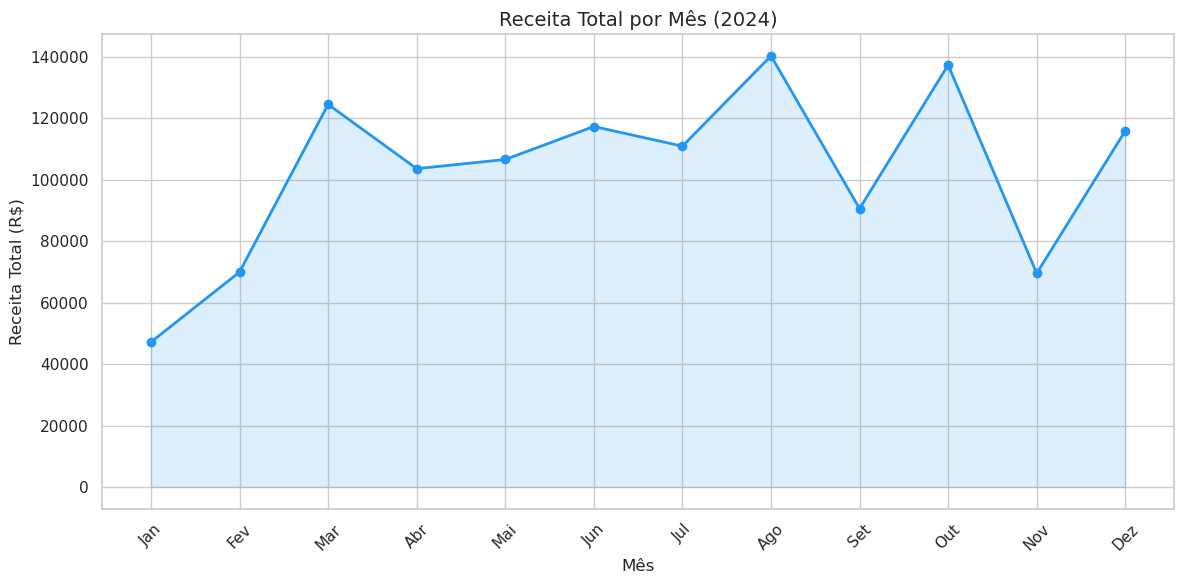

  Gráfico exportado: outputs/graficos/vendas_por_mes.png



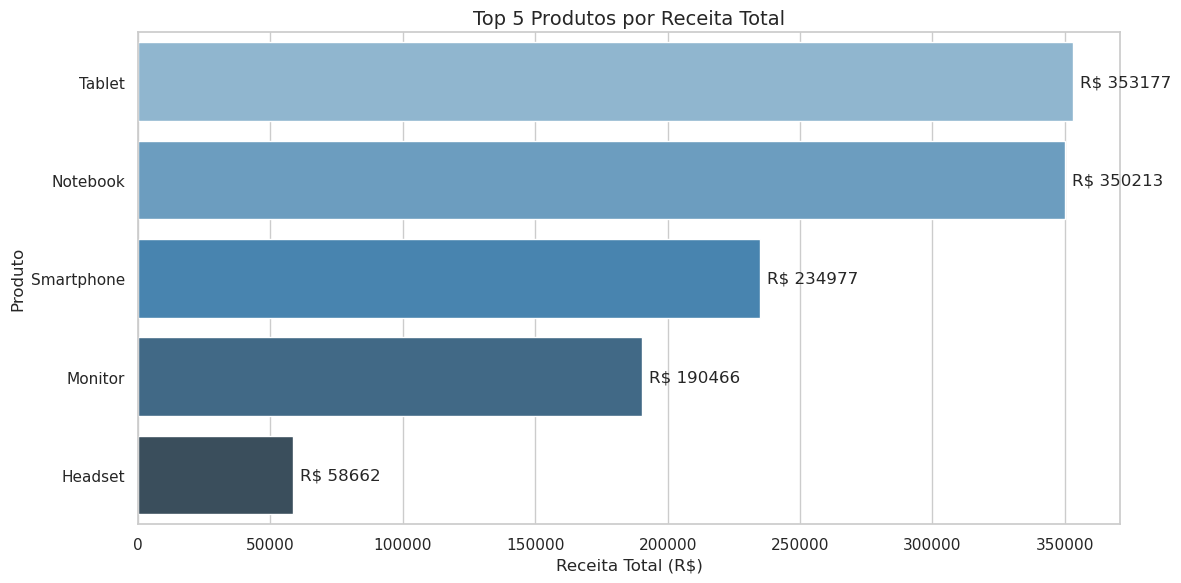

  Gráfico exportado: outputs/graficos/top_produtos.png



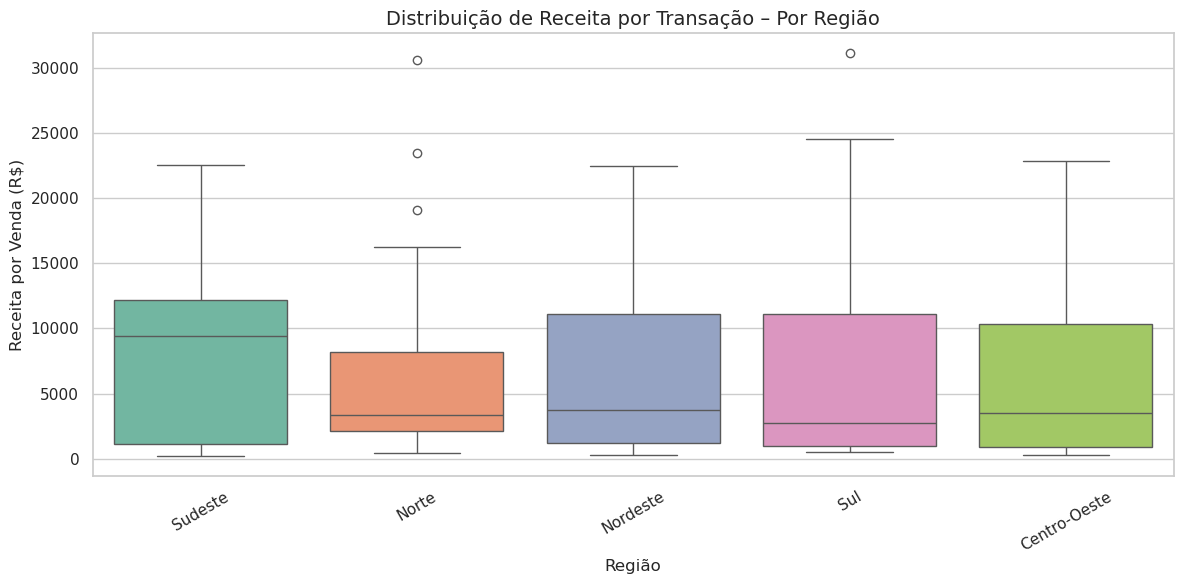

  Gráfico exportado: outputs/graficos/distribuicao_regioes.png

**VISUALIZAÇÕES GERADAS COM SUCESSO ------------------------------------------------------------


In [93]:
gerar_visualizacoes(df_novo, metricas)